# Exercice 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('votes_repub.csv', index_col=0)
df.head()

,X1856,X1860,X1864,X1868,X1872,X1876,X1880,X1884,X1888,X1892,...,X1940,X1944,X1948,X1952,X1956,X1960,X1964,X1968,X1972,X1976
California,18.77,32.96,58.63,50.24,56.38,50.88,48.92,52.08,49.95,43.76,...,41.35,42.99,47.14,56.39,55.40,50.10,40.9,47.8,55.0,50.89
Connecticut,53.18,53.86,51.38,51.54,52.25,48.34,50.52,48.01,48.44,46.80,...,46.30,46.94,49.55,55.70,63.73,46.27,32.2,44.3,58.6,52.64
Delaware,2.11,23.71,48.20,40.98,50.99,44.55,47.86,42.75,43.55,48.55,...,45.05,45.27,50.04,51.75,55.09,49.00,39.1,45.1,59.6,47.27
Illinois,40.25,50.68,54.41,55.69,56.27,50.09,51.11,50.16,49.54,45.70,...,48.54,48.05,49.24,54.84,59.52,49.80,40.5,47.1,59.0,51.11
Indiana,40.03,51.09,53.60,51.39,53.00,48.27,49.33,48.16,49.05,46.17,...,50.45,52.38,49.58,58.11,59.90,55.03,44.0,50.3,66.1,53.77


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19 entries, California to Wisconsin
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1856   19 non-null     float64
 1   X1860   19 non-null     float64
 2   X1864   19 non-null     float64
 3   X1868   19 non-null     float64
 4   X1872   19 non-null     float64
 5   X1876   19 non-null     float64
 6   X1880   19 non-null     float64
 7   X1884   19 non-null     float64
 8   X1888   19 non-null     float64
 9   X1892   19 non-null     float64
 10  X1896   19 non-null     float64
 11  X1900   19 non-null     float64
 12  X1904   19 non-null     float64
 13  X1908   19 non-null     float64
 14  X1912   19 non-null     float64
 15  X1916   19 non-null     float64
 16  X1920   19 non-null     float64
 17  X1924   19 non-null     float64
 18  X1928   19 non-null     float64
 19  X1932   19 non-null     float64
 20  X1936   19 non-null     float64
 21  X1940   19 non-null     float6

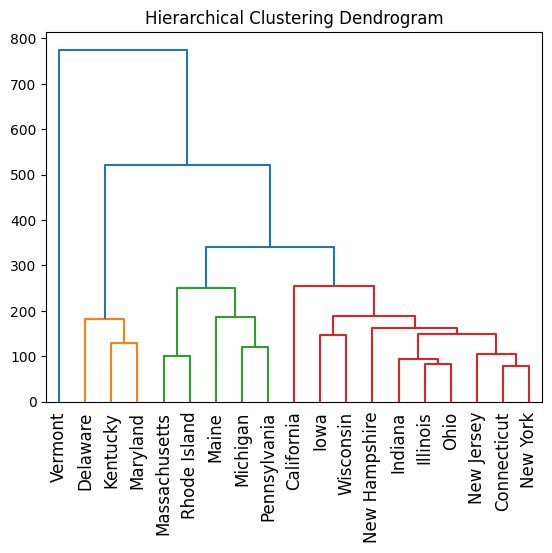

In [4]:
# Hierarchical clustering
clusters = linkage(pdist(df, metric = 'cityblock'), method = 'complete')

dendrogram(clusters,
           labels = df.index,
           color_threshold = 300)
plt.title('Hierarchical Clustering Dendrogram')
plt.xticks(rotation=90)
plt.show()

In [5]:
# PCA
pca = PCA()
components = pca.fit_transform(df)
df_results = pd.DataFrame(components).iloc[:, [0, 1]]
df_results.rename(columns = {0: 'PC1', 1: 'PC2'}, inplace = True)

In [6]:
# Cut tree
df_results['Cluster'] = cut_tree(clusters, n_clusters = 4).reshape(-1, )
df_results['State'] = df.index
df_results.head()

,PC1,PC2,Cluster,State
0,-29.518254,7.280302,0,California
1,6.964863,-8.751167,0,Connecticut
2,-49.061627,12.460308,1,Delaware
3,-2.967403,-1.868477,0,Illinois
4,-10.452302,2.372719,0,Indiana


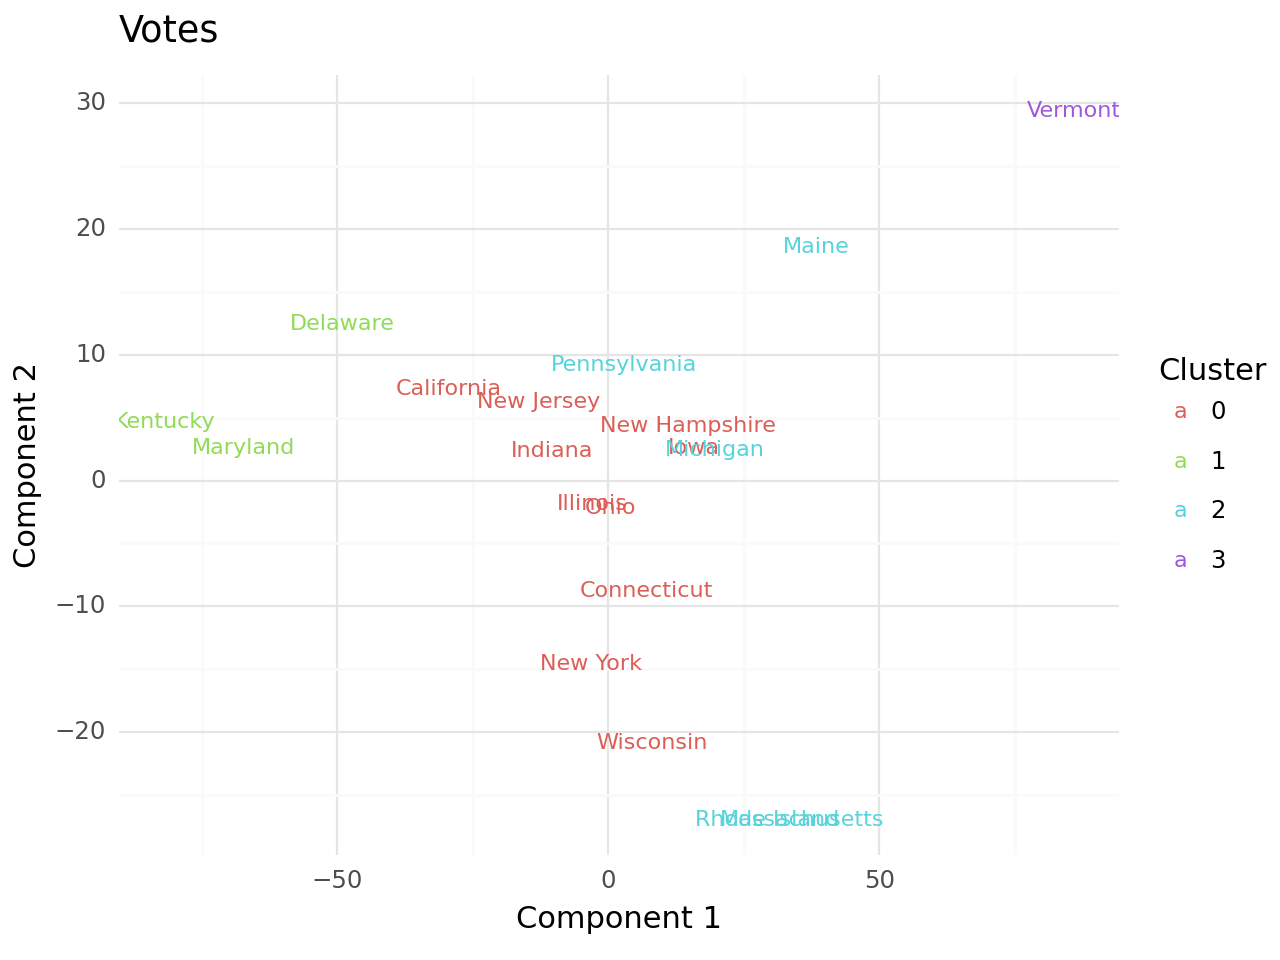

<Figure Size: (640 x 480)>

In [8]:
# Plot
from plotnine import ggplot, aes, geom_text, labs, theme_minimal, guides, guide_legend

(
    ggplot(df_results,
           aes(x = 'PC1',
               y = 'PC2',
               color = 'factor(Cluster)',
               label = 'State'))
    #+geom_point()
    +geom_text(size = 8)
    +labs(title = 'Votes',
         x = 'Component 1',
         y = 'Component 2')
    +guides(color = guide_legend(title = 'Cluster'))
    +theme_minimal()
)